In [1]:
# solver for Yukawa potential
# central field potential - use radial schrodinger eqn

In [1]:
# ========================
# Import Packages/Modules
# ========================
import matplotlib.pyplot as plt           # from hydrogen.py
import numpy as np                        # from hydrogen.py
#import vpython as vp
#vec = vp.vector
#from scipy.constants import e, hbar, m_p  # for numerical values of q_e, hbar, m_p
from jwanglibs import rootfinder as rtf   # from hydrogen.py
from scipy.constants import m_p, m_n

In [3]:
# =================================
# Conversions to MeV/Natural Units
# =================================
# Proton Mass
mP = m_p  # kg
mP = mP*1e30  # change order scale
mP = mP/1.783  # MeV/c^2, but c = 1 in natural units
print('mP = %.5f MeV' %mP)  # MeV

# Neutron Mass
mN = m_n  # kg
mN = mN*1e30  # change order scale
mN = mN/1.783  # MeV/c^2, but c = 1 in natural units
print('mN = %.5f MeV' %mN)  # MeV

# ===================
# Initial Conditions
# ===================
xL, xR, N = 10e-6, 120., 2200     # limits, interval
hbar, V0 = 1.0, 1.0      # constants
m = 1.0
a = 1.0                           # radius of potential well [L]^1 (fm)
lamda = 0.0                       # yukawa interaction range [L]^-1 (fm^-1)
h = (xR-xL)/N                     # step size
Lmax, EL = 4, []                  # define max L, blank L array
M = N // 2                        # M = matching point
print('a = %.1f fm' %a)  # fm

mP = 938.09418 MeV
mN = 939.38727 MeV
a = 1.0 fm


In [11]:
#For now, we will be using 1.0 for our constants for easy calculation and visualization.

In [2]:
# ========================
# Define Yukawa Potential
# ========================
def V(r):
    '''
    if r <= a:
        return -V0                     # potential well inside nuclear radius
    else:
        return np.exp(-lamda*r)/r  # exponential decay outside well
    '''
    return np.where(r <= a, -V0, np.exp(-lamda*r)/r)

In [3]:
# =============================
# Define Centrifugal Potential
# =============================
def centrifugal(r):
    return hbar**2*L*(L+1)/(2*m*r**2)

In [4]:
# ===========================
# Define Effective Potential
# ===========================
def V_eff(r):                                                  # effective potential
    '''
    from hydrogen.py
    return L*(L+1)/(2*m*r**2) - 1/(4*pi*)/r                    # centrifugal + coulomb
    '''
    return centrifugal(r) + V(r)  # centrifugal + yukawa
    #return np.where(r <= a, V(r), centrifugal(r) + V(r))  # centrifugal + yukawa


In [5]:
# ========================
# Define Numerov Schr Eqn
# ========================
def f(r):                            # Sch eqn in Numerov form
    return 2*m*(E-V_eff(r))/hbar**2  #rearrange radial Sch eqn

In [6]:
# ====================
# Define Numerov func
# ====================
def numerov(f, u, n, x, h):     # Numerov integrator for $u''+f(x)u=0$
    nodes, c = 0, h**2/12.       # given $[u_0,u_1]$, return $[u_0,u_1,...,u_{n+1}]$
    f0, f1 = f(x), f(x+h)
    for i in range(n):
        x += h
        f2 = f(x+h)             # Numerov method below, 
        u.append((2*(1-5*c*f1)*u[i+1] - (1+c*f0)*u[i])/(1+c*f2))  # Numerov update
        f0, f1 = f1, f2
        if u[-1]*u[-2] < 0.0:
            nodes += 1
    return u, nodes             # return u, nodes

In [7]:
# ==================
# Define shoot func
# ==================
def shoot(En):
    global E                    # E needed in f(r)
    E, c, xm = En, (h**2)/6., xL + M*h
    wfup, nup = numerov(f, [0,.1], M, xL, h)  # outward integration from left
    wfdn, ndn = numerov(f, [0,.1], N-M, xR, -h)  # inward integration from right
    dup = ((1+c*f(xm+h))*wfup[-1] - (1+c*f(xm-h))*wfup[-3])/(h+h)
    ddn = ((1+c*f(xm+h))*wfdn[-3] - (1+c*f(xm-h))*wfdn[-1])/(h+h)
    return dup*wfdn[-2] - wfup[-2]*ddn

In [12]:
# ===================
# Initial Conditions
# ===================
xL, xR, N = 10e-6, 12., 3000    # limits, interval
hbar, V0 = 1.0, 10.0               # constants
m = 1.0
#m = mP                            # mass of proton
a = 2.0                       # radius of potential well [L]^1 (fm)
lamda = 0.2                       # yukawa interaction range [L]^-1 (fm^-1)
h = (xR-xL)/N                     # step size
Lmax, EL = 4, []                  # define max L, blank L array
M = int(a*N/xR)                         # M = matching point

In [13]:
# ================================================
# Calculate energy for n, l, and associated nodes
# ================================================
Estart, dE = -V0-0.1, 0.001      # scan from lower bound -V0
list_psix = [[] for _ in range(Lmax)]

for L in range(Lmax):
    n, E1, Ea = L+1, Estart, []
    while (E1 < -4*dE):             # sweep E range for each L for pure bound states (E < 0)
    #while (E1 < np.exp(-lamda*a)/a):             # sweep E range for each L until upper well bound
        E1 += dE
        if (shoot(E1)*shoot(E1 + dE) > 0):
            continue
        E = rtf.bisect(shoot, E1, E1 + dE, 1.e-8)
        Ea.append(E)  # append E value to energy array Ea
        wfup, nup = numerov(f, [0,.1], M-1, xL, h)      # calc wf
        wfdn, ndn = numerov(f, [0,.1], N-M-1, xR, -h)
        psix = np.concatenate((wfup[:-1], wfdn[::-1]))
        psix[M:] *= wfup[-1]/wfdn[-1]                   # match
        list_psix[L].append(psix)
        
        print ('nodes = %i, n = %i,l = %i, E = %.8e' %(nup+ndn, n, L, E))
        n += 1
    EL.append(Ea)

nodes = 0, n = 1,l = 0, E = -9.00044241e+00
nodes = 1, n = 2,l = 0, E = -6.05018061e+00
nodes = 2, n = 3,l = 0, E = -1.42544768e+00
nodes = 0, n = 2,l = 1, E = -7.96144126e+00
nodes = 1, n = 3,l = 1, E = -4.08770949e+00
nodes = 0, n = 3,l = 2, E = -6.65832647e+00
nodes = 1, n = 4,l = 2, E = -1.91915357e+00
nodes = 0, n = 4,l = 3, E = -5.10856387e+00


<>:18: SyntaxWarning: invalid escape sequence '\e'
<>:18: SyntaxWarning: invalid escape sequence '\e'
/var/folders/0g/j1m3j1kj205g8kh8b2z5kdcm0000gn/T/ipykernel_30623/3978267117.py:18: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('$\ell$'), plt.ylabel('$E$')


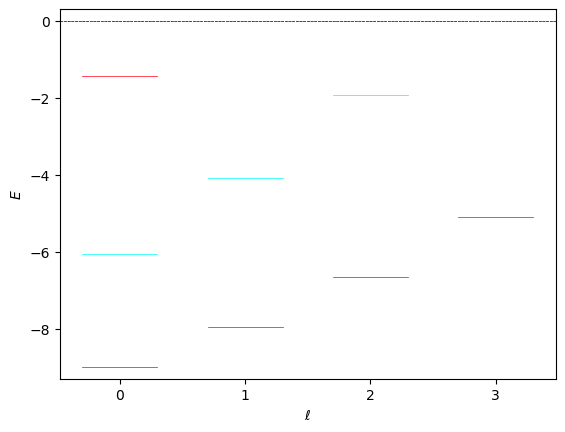

In [14]:
# =========
# Plotting
# =========
# Some code for plotting added with help of Claude
import matplotlib.cm as cm
import numpy as np

# Create a colormap for different n-values
max_n = max(len(EL[L]) for L in range(Lmax))  # Find max number of n-values
colors = cm.hsv(np.linspace(0, 1, max_n))

plt.figure()                        # plot energy levels
for L in range(Lmax):
    for i in range(len(EL[L])):
        plt.plot([L-.3, L+.3], [EL[L][i]]*2, color=colors[i], lw=0.5, label=f'n={i+1}' if L == 0 else '')
    plt.axhline(0, color='r', ls='--', lw=0.5)
    #plt.axhline(EL[L][-1]+0.1, color='b', ls='--', lw=0.5)
    plt.xlabel('$\ell$'), plt.ylabel('$E$')
    plt.ylim(EL[0][0]-0.3, 0.3), plt.xticks(range(Lmax))

#plt.legend(loc='best')
plt.show()

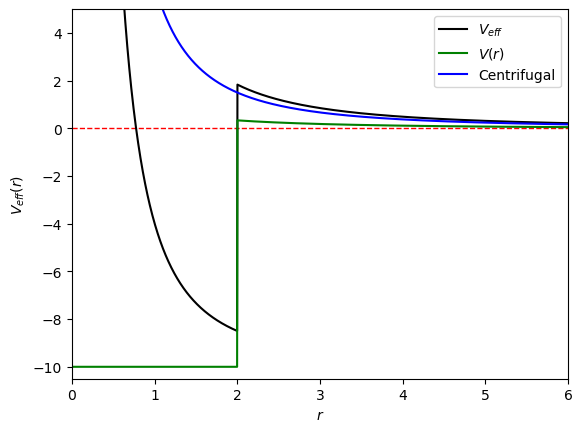

In [15]:
# plot potential
r = np.linspace(xL, xR, N)  # r range

plt.figure()
plt.axhline(0, color='r', linestyle='--', linewidth=1)  # dashed x-axis
plt.plot(r, V_eff(r), 'k-', label='$V_{eff}$')
plt.plot(r, V(r), 'g-', label='$V(r)$')
plt.plot(r, centrifugal(r), 'b-', label='Centrifugal')
plt.xlim(0, 6)
plt.ylim(-V0-0.5, 5)
plt.xlabel('$r$')
plt.ylabel('$V_{eff}(r)$')
plt.legend()
plt.show()

<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:16: SyntaxWarning: invalid escape sequence '\e'
/var/folders/0g/j1m3j1kj205g8kh8b2z5kdcm0000gn/T/ipykernel_30623/2986750523.py:16: SyntaxWarning: invalid escape sequence '\e'
  plt.title(f'Reduced Radial Wave Function: $n={L+i+1}$, $\ell = {L}$')


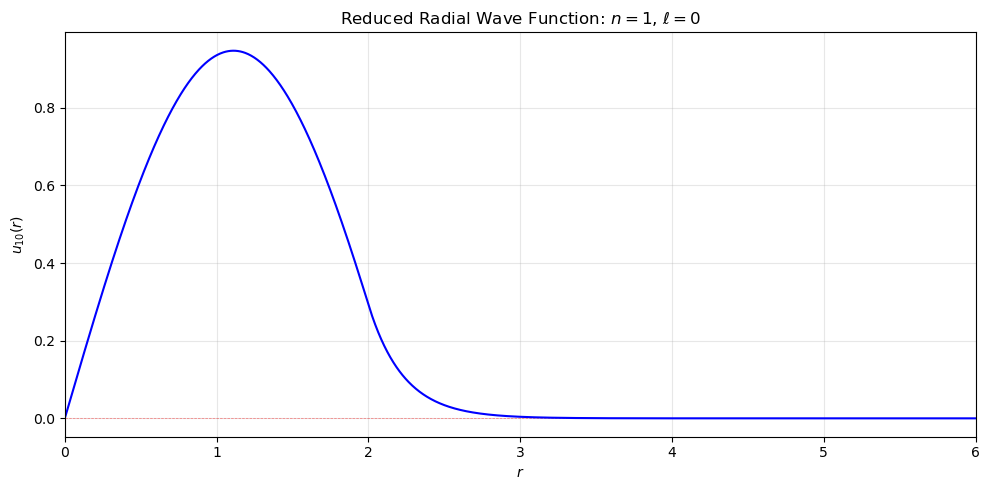

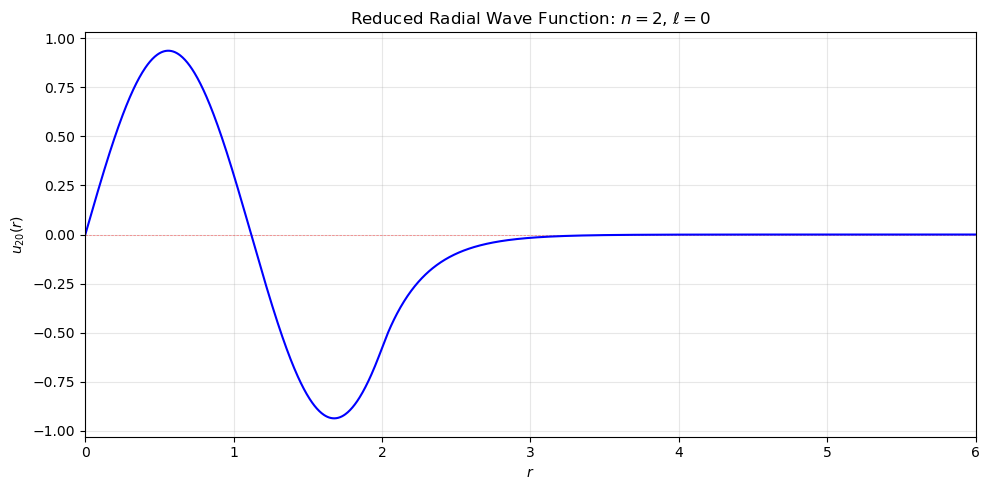

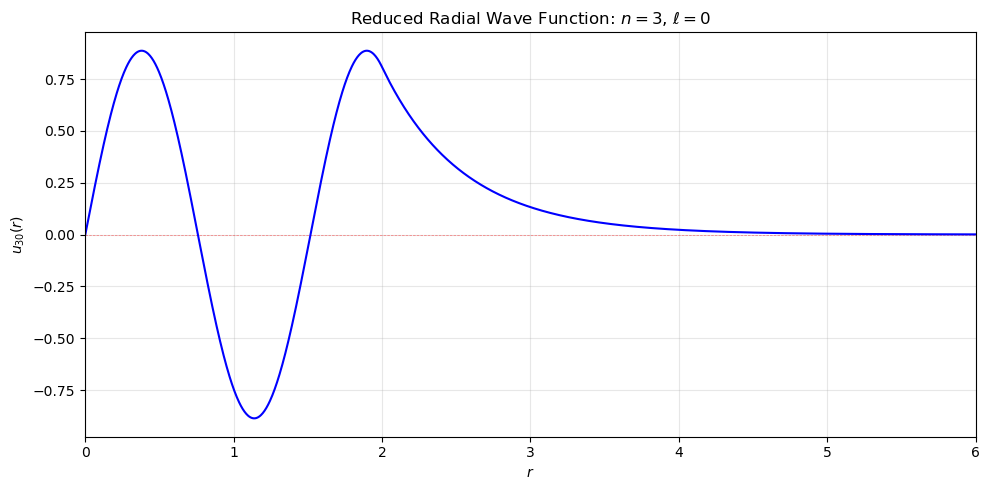

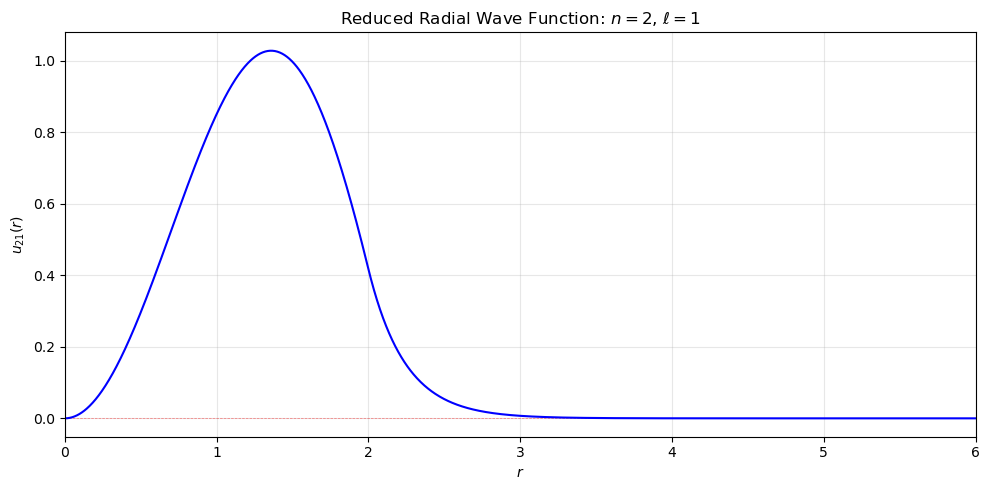

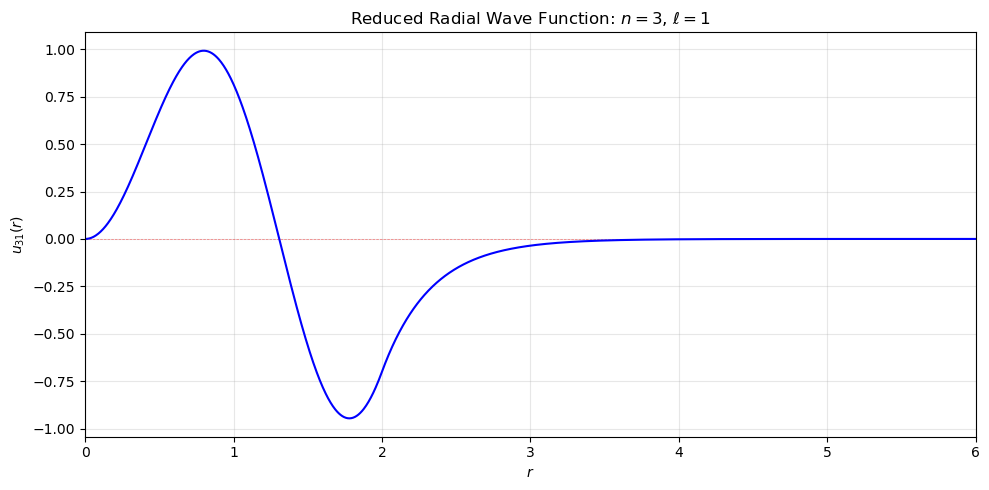

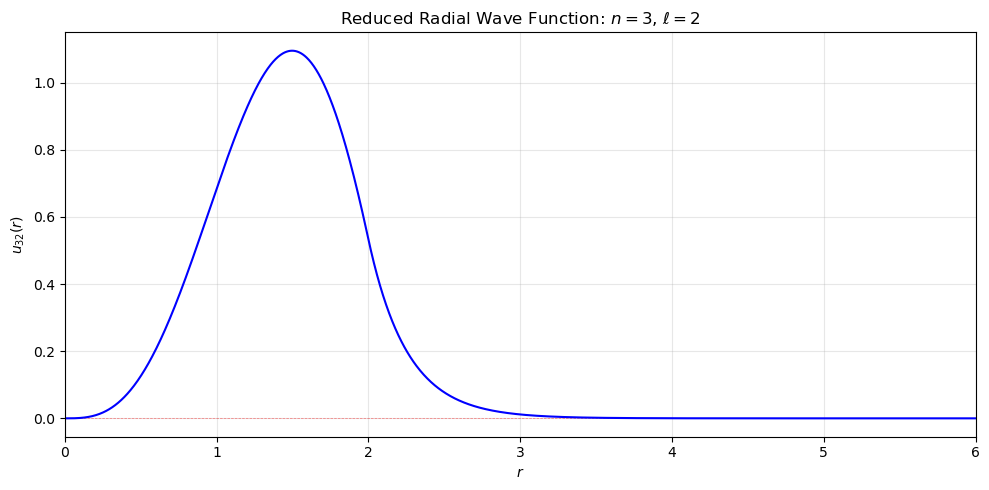

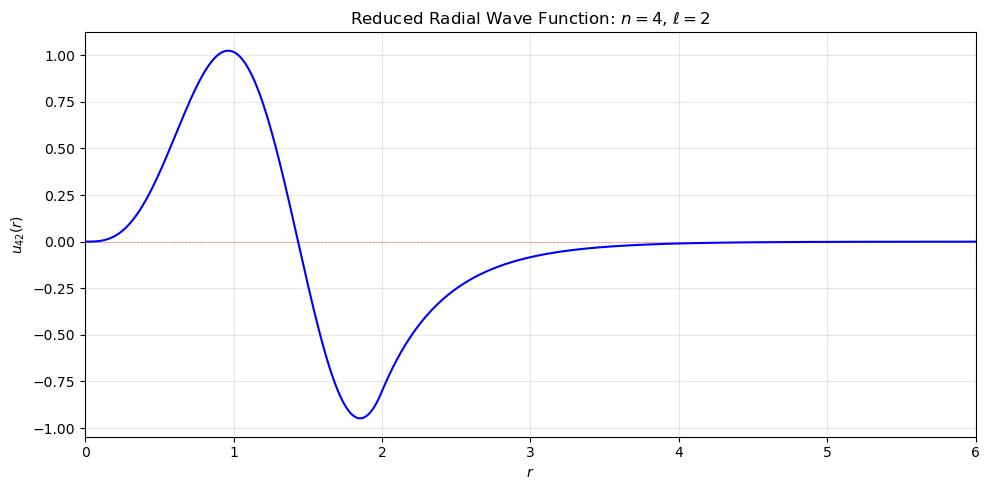

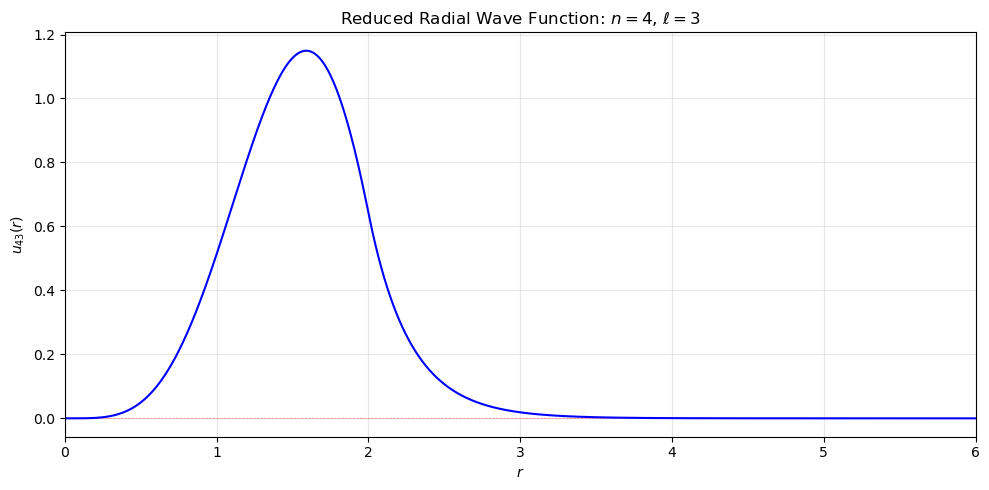

In [16]:
# plot normalized reduced radial wave functions for all L and n values
from scipy.integrate import trapezoid

for L in range(Lmax):
    for i, psi in enumerate(list_psix[L]):
        plt.figure(figsize=(10, 5))
        plt.axhline(0, color='r', ls='--', lw=0.5, alpha=0.5)
        
        psi_truncated = psi[:len(r)]
        norm = np.sqrt(trapezoid(psi_truncated**2, r)) # normalize
        psi_normalized = psi_truncated / norm
        plt.plot(r, psi_normalized, lw=1.5, color='b')
        
        plt.xlabel('$r$')
        plt.ylabel(f'$u_{{{L+i+1}{L}}}(r)$')
        plt.title(f'Reduced Radial Wave Function: $n={L+i+1}$, $\ell = {L}$')
        plt.grid(True, alpha=0.3)
        plt.xlim(0, 6)  # Focus on region near potential well
        plt.tight_layout()
        plt.show()